# 📘 Week 2: Sampling & Aliasing

## 🎯 Objectives:
- Understand the concept of sampling in time domain
- Explore Nyquist rate and aliasing
- Visualize undersampling effects
- Experiment with reconstruction techniques

## 🎵 Original Signal (High Frequency Sine)
Let's generate a high-frequency sine wave and plot it in continuous form.

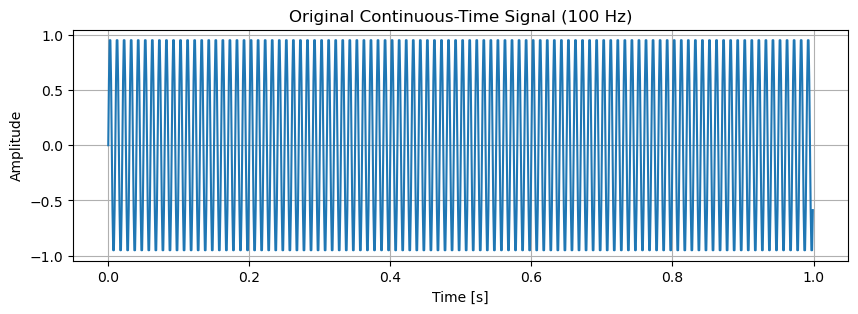

In [1]:
import numpy as np
import matplotlib.pyplot as plt

fs_cont = 1000  # High sample rate
t_cont = np.linspace(0, 1, fs_cont, endpoint=False)
f = 100  # Frequency of sine wave
signal_cont = np.sin(2 * np.pi * f * t_cont)

plt.figure(figsize=(10, 3))
plt.plot(t_cont, signal_cont)
plt.title('Original Continuous-Time Signal (100 Hz)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

## 🔄 Sampling at Different Rates
- Nyquist rate: $2f = 200$ Hz
- Undersampling at 150 Hz and 80 Hz

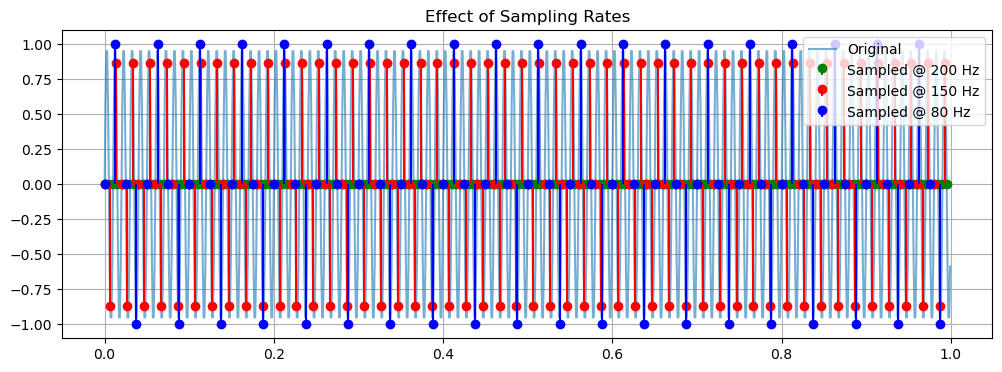

In [2]:
def sample_and_plot(fs, color):
    t = np.linspace(0, 1, fs, endpoint=False)
    samples = np.sin(2 * np.pi * f * t)
    plt.stem(t, samples, linefmt=color, markerfmt=color+'o', basefmt=' ', label=f'Sampled @ {fs} Hz')

plt.figure(figsize=(12, 4))
plt.plot(t_cont, signal_cont, label='Original', alpha=0.6)
sample_and_plot(200, 'g')
sample_and_plot(150, 'r')
sample_and_plot(80, 'b')
plt.title('Effect of Sampling Rates')
plt.legend()
plt.grid(True)
plt.show()

## 🌀 Aliasing Demonstration
- Show how a 100 Hz sine wave appears if sampled at 80 Hz
- Alias frequency = |f - fs| = |100 - 80| = 20 Hz (wrong frequency!)

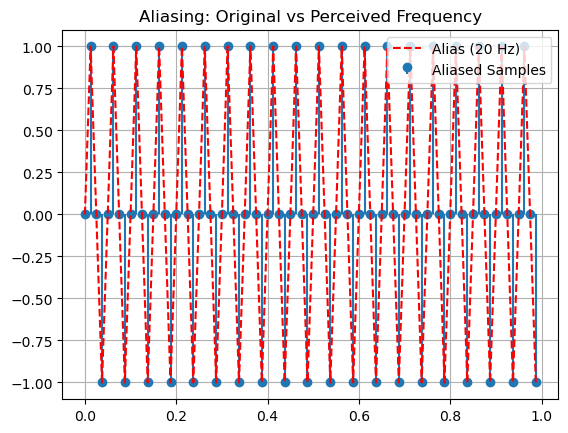

In [3]:
fs_alias = 80
t_alias = np.linspace(0, 1, fs_alias, endpoint=False)
samples_alias = np.sin(2 * np.pi * f * t_alias)

plt.stem(t_alias, samples_alias, basefmt=' ', label='Aliased Samples')
plt.plot(t_alias, np.sin(2 * np.pi * 20 * t_alias), 'r--', label='Alias (20 Hz)')
plt.title('Aliasing: Original vs Perceived Frequency')
plt.legend()
plt.grid(True)
plt.show()

## 🔁 Interpolation (Reconstruction)
- Reconstruct signal using zero-order hold and sinc interpolation

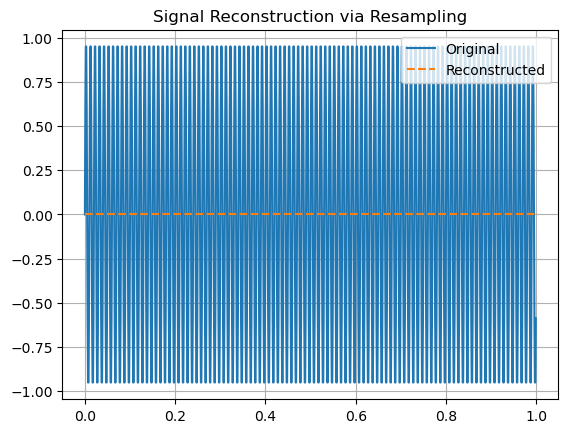

In [4]:
from scipy.signal import resample

fs_sample = 200
t_sample = np.linspace(0, 1, fs_sample, endpoint=False)
samples = np.sin(2 * np.pi * f * t_sample)
t_interp = np.linspace(0, 1, fs_cont, endpoint=False)
signal_interp = resample(samples, fs_cont)

plt.plot(t_cont, signal_cont, label='Original')
plt.plot(t_interp, signal_interp, '--', label='Reconstructed')
plt.legend()
plt.title('Signal Reconstruction via Resampling')
plt.grid(True)
plt.show()

## ✅ Reflection:
- What happens when you undersample a signal?
- How is aliasing detected visually?
- What are the limitations of signal reconstruction?